# FruitVision — Fase 3: Preparación de los Datos

**Proyecto final:** FruitVision  
**Curso:** Algoritmos y Programación III — Semestre 2026-1  
**Integrantes:** Juan José Gordillo Córdoba · Sebastián Jiménez Galvis · Juan Pablo Zambrano Cortez

Este notebook convierte el catálogo crudo en un dataset limpio, balanceado, segmentado y listo para Fase 4.

| Paso | Tarea | Estado |
|------|-------|--------|
| 0 | Configuración del entorno | ✓ |
| 1 | Carga del catálogo maestro | ✓ |
| 2 | Cap Premium por fruta (downsampling) | ✓ |
| 3 | Split estratificado 70/15/15 | ✓ |
| 4 | Pipeline de segmentación OpenCV | ✓ |
| 5 | Construcción de instancias segmentadas | ✓ |
| 6 | Augmentación de Estándar + guardado en disco | ✓ |
| 7 | Umbrales de tamaño (quantiles sobre train) | ✓ |
| 8 | Guardado de instancias y manifests CSV | ✓ |
| 9 | Validaciones de integridad | ✓ |
| 10 | Visualización de muestras finales | ✓ |

## 0. Configuración del entorno

In [1]:
# ============================================================
# 0. Configuración del entorno
# ============================================================
import math
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

try:
    import albumentations as A
except ImportError as exc:
    raise ImportError("Este notebook requiere albumentations. Instalar con: pip install albumentations") from exc

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Localización automática de la raíz del proyecto ──────────────────────────
ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA_EXTERNAL  = ROOT / "data" / "external"
DATA_OWN       = ROOT / "data" / "own"
DATA_ANNOT     = ROOT / "data" / "annotations"
DATA_PROCESSED = ROOT / "data" / "processed" / "fase3"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Mappings de calidad y tamaño ─────────────────────────────────────────────
QUALITY_TO_ID = {"Premium": 0, "Estándar": 1, "Descarte": 2}
ID_TO_QUALITY = {v: k for k, v in QUALITY_TO_ID.items()}
SIZE_TO_ID    = {"Pequeño": 0, "Mediano": 1, "Grande": 2}
ID_TO_SIZE    = {v: k for k, v in SIZE_TO_ID.items()}

IMG_EXTENSIONS  = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

KAGGLE_FOLDER_MAP = {
    "Good Quality_Fruits" : ("Premium",  "Good"),
    "Bad Quality_Fruits"  : ("Descarte", "Bad"),
    "Mixed Qualit_Fruits" : ("Mixed",    "Mixed"),
}

OWN_QUALITY_ALIASES = {
    "premium" : "Premium",
    "estandar": "Estándar",
    "standard": "Estándar",
    "descarte": "Descarte",
    "bad"     : "Descarte",
    "good"    : "Premium",
    "mixed"   : "Estándar",
}

QUALITY_PALETTE = {
    "Premium" : "#2ecc71",
    "Estándar": "#f39c12",
    "Descarte": "#e74c3c",
    "Mixed"   : "#9b59b6",
}
QUALITY_ORDER = ["Premium", "Estándar", "Descarte"]

# ── Hiperparámetros de la fase ────────────────────────────────────────────────
CAP_PREMIUM_PER_FRUIT  = 1200   # máx imágenes Premium por fruta (downsampling)
TARGET_SIZE            = (256, 256)
# FIX-E: diagonal del crop post-resize es siempre 256√2 ≈ 362 px.
# Usaremos esta constante para normalizar el diámetro en TODOS los casos.
CROP_DIAGONAL_PX       = float(np.sqrt(256**2 + 256**2))   # ≈ 362.04
MIN_AREA_RATIO         = 0.01   # área mínima de contorno como fracción del área total
DAMAGE_PREMIUM_MAX     = 2.0    # umbral máx de daño (%) para clasificar como Premium
DAMAGE_STANDARD_MAX    = 18.0   # umbral máx de daño (%) para clasificar como Estándar
# FIX-C: cap de multiplicador de augmentación para evitar oversampling extremo.
# Si Estándar tiene pocas instancias, no se replica más de MAX_AUG_MULTIPLIER veces.
MAX_AUG_MULTIPLIER     = 4

print(f"Raíz del proyecto   : {ROOT}")
print(f"Imágenes procesadas : {DATA_PROCESSED}")
print(f"Diagonal constante  : {CROP_DIAGONAL_PX:.2f} px  (normalizador de diámetro)")

Raíz del proyecto   : c:\Users\juanj\Downloads\fruit-quality-repo (2)\fruit-quality-repo
Imágenes procesadas : c:\Users\juanj\Downloads\fruit-quality-repo (2)\fruit-quality-repo\data\processed\fase3
Diagonal constante  : 362.04 px  (normalizador de diámetro)


## 1. Carga del catálogo maestro

In [2]:
def resolve_path(path_value: str) -> Path:
    p = Path(str(path_value))
    if p.is_absolute():
        return p
    candidate = (ROOT / p).resolve()
    if candidate.exists():
        return candidate
    return p.resolve()


def safe_imread_bgr(path_value: str) -> Optional[np.ndarray]:
    try:
        return cv2.imread(str(path_value))
    except Exception:
        return None


def normalize_quality_name(text: str) -> Optional[str]:
    if text is None:
        return None
    key = str(text).strip().lower()
    for alias, canonical in OWN_QUALITY_ALIASES.items():
        if alias in key:
            return canonical
    if "mixed" in key:
        return "Mixed"
    return None


def infer_fruit_from_folder(folder_name: str) -> str:
    if not folder_name:
        return "Desconocida"
    return str(folder_name).split("_")[0].strip()


def discover_kaggle_catalog(base_path: Path) -> pd.DataFrame:
    records: List[Dict] = []
    for folder_name, (quality_name, folder_label) in KAGGLE_FOLDER_MAP.items():
        folder_dir = base_path / folder_name
        if not folder_dir.exists():
            continue
        for fruit_dir in sorted(folder_dir.iterdir()):
            if not fruit_dir.is_dir():
                continue
            fruit = infer_fruit_from_folder(fruit_dir.name)
            for img_path in sorted(fruit_dir.iterdir()):
                if img_path.suffix.lower() not in IMG_EXTENSIONS:
                    continue
                records.append({
                    "source_domain": "Kaggle",
                    "origin_folder": folder_name,
                    "folder_label" : folder_label,
                    "fruit"        : fruit,
                    "quality_hint" : quality_name,
                    "path"         : str(img_path.resolve()),
                })
    return pd.DataFrame(records)


def discover_own_catalog(own_path: Path) -> pd.DataFrame:
    records: List[Dict] = []
    if not own_path.exists():
        return pd.DataFrame(records)
    for img_path in sorted(own_path.rglob("*")):
        if not img_path.is_file() or img_path.suffix.lower() not in IMG_EXTENSIONS:
            continue
        ancestors = [p.name for p in img_path.parents]
        quality   = None
        fruit     = "Desconocida"
        for ancestor in ancestors:
            q = normalize_quality_name(ancestor)
            if q is not None:
                quality = q
                break
        parent_name = img_path.parent.name
        if normalize_quality_name(parent_name) is None and parent_name:
            fruit = infer_fruit_from_folder(parent_name)
        if fruit == "Desconocida" and img_path.parent.parent != img_path.parent:
            maybe_fruit = img_path.parent.parent.name
            if normalize_quality_name(maybe_fruit) is None:
                fruit = infer_fruit_from_folder(maybe_fruit)
        records.append({
            "source_domain": "Own",
            "origin_folder": "Own",
            "folder_label" : "Own",
            "fruit"        : fruit,
            "quality_hint" : quality,
            "path"         : str(img_path.resolve()),
        })
    return pd.DataFrame(records)


def load_master_catalog() -> pd.DataFrame:
    """
    Carga el catálogo maestro preferiblemente desde labels.csv generado en Fase 2.
    Si no existe, descubre las imágenes directamente desde el sistema de archivos.
    """
    labels_csv = DATA_ANNOT / "labels.csv"
    if labels_csv.exists():
        df = pd.read_csv(labels_csv)
        if "path" not in df.columns:
            raise ValueError("labels.csv existe pero no contiene la columna 'path'.")
        if "quality" not in df.columns:
            if "label" in df.columns:
                inv = {0: "Premium", 1: "Estándar", 2: "Descarte", -1: "Mixed"}
                df["quality"] = df["label"].map(inv)
            else:
                raise ValueError("No encuentro columnas 'quality' ni 'label' en labels.csv.")
        if "source" not in df.columns:
            df["source"] = "Kaggle"
        if "fruit" not in df.columns:
            df["fruit"] = df["path"].apply(
                lambda x: infer_fruit_from_folder(Path(str(x)).parent.name)
            )
        if "folder" not in df.columns:
            df["folder"] = df["quality"].replace({
                "Premium" : "Good", "Descarte": "Bad",
                "Mixed"   : "Mixed", "Estándar": "Mixed",
            })
        df["source_domain"] = df["source"].replace({"Propio": "Own"}).fillna("Kaggle")
        df["path"]          = df["path"].astype(str).map(lambda x: str(resolve_path(x)))
        df["quality_hint"]  = df["quality"].fillna("Desconocida")
        df["origin_folder"] = df.get("origin_folder", df["folder"]).astype(str)
        df["folder_label"]  = df.get("folder", df["origin_folder"]).astype(str)
        return df[["source_domain","origin_folder","folder_label","fruit","quality_hint","path"]].dropna(subset=["path"])

    kaggle = discover_kaggle_catalog(DATA_EXTERNAL)
    own    = discover_own_catalog(DATA_OWN)
    return pd.concat([kaggle, own], ignore_index=True)


raw_catalog = load_master_catalog()
raw_catalog["path"] = raw_catalog["path"].map(lambda p: str(resolve_path(p)))
raw_catalog = raw_catalog[raw_catalog["path"].map(lambda p: Path(p).exists())].copy()
raw_catalog.reset_index(drop=True, inplace=True)

print(f"Imágenes en catálogo bruto : {len(raw_catalog):,}")
print(raw_catalog["quality_hint"].value_counts())
raw_catalog.head()

Imágenes en catálogo bruto : 29,041
quality_hint
Premium     11664
Descarte     6788
estandar     4612
premium      2659
descarte     2244
Mixed        1074
Name: count, dtype: int64


,source_domain,origin_folder,folder_label,fruit,quality_hint,path
0,Kaggle,Good,Good,Apple,Premium,C:\Users\juanj\Downloads\fruit-quality-repo (2...
1,Kaggle,Good,Good,Apple,Premium,C:\Users\juanj\Downloads\fruit-quality-repo (2...
2,Kaggle,Good,Good,Apple,Premium,C:\Users\juanj\Downloads\fruit-quality-repo (2...
3,Kaggle,Good,Good,Apple,Premium,C:\Users\juanj\Downloads\fruit-quality-repo (2...
4,Kaggle,Good,Good,Apple,Premium,C:\Users\juanj\Downloads\fruit-quality-repo (2...


## 2. Cap Premium por fruta (downsampling)

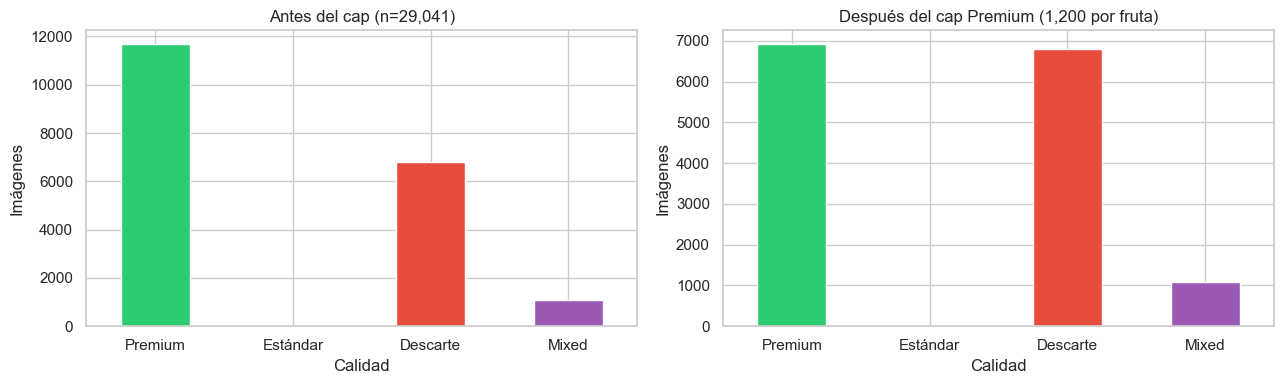

Conteos tras cap:
quality_hint
Premium     6908
Descarte    6788
estandar    4612
premium     2659
descarte    2244
Mixed       1074
Name: count, dtype: int64


In [3]:
def cap_premium_by_fruit(df: pd.DataFrame, cap_per_fruit: int = CAP_PREMIUM_PER_FRUIT) -> pd.DataFrame:
    """
    Submuestreo aleatorio sobre la clase Premium.

    Objetivo: limitar el sesgo inducido por Pomegranate_Good (sobreinflada según EDA).
    El cap se aplica por fruta dentro de Premium, no sobre el total de la clase,
    preservando la diversidad de especies.

    Parámetros
    ----------
    cap_per_fruit : int   Máximo de imágenes Premium permitidas por fruta (default: 1200).
    """
    premium = df[df["quality_hint"].eq("Premium")].copy()
    others  = df[~df["quality_hint"].eq("Premium")].copy()

    kept_frames = []
    for fruit, grp in premium.groupby("fruit", dropna=False):
        kept_frames.append(grp.sample(min(len(grp), cap_per_fruit), random_state=SEED))

    premium_capped = (pd.concat(kept_frames, ignore_index=True)
                      if kept_frames else premium.iloc[0:0].copy())
    capped = pd.concat([premium_capped, others], ignore_index=True)
    return capped.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


catalog_capped = cap_premium_by_fruit(raw_catalog, CAP_PREMIUM_PER_FRUIT)

before_counts = raw_catalog["quality_hint"].value_counts()
after_counts  = catalog_capped["quality_hint"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, counts, title in [
    (axes[0], before_counts, f"Antes del cap (n={len(raw_catalog):,})"),
    (axes[1], after_counts,  f"Después del cap Premium ({CAP_PREMIUM_PER_FRUIT:,} por fruta)"),
]:
    idx = QUALITY_ORDER + ["Mixed"]
    counts.reindex(idx).fillna(0).plot.bar(
        ax=ax,
        color=[QUALITY_PALETTE.get(x, "#999999") for x in idx]
    )
    ax.set_title(title); ax.set_xlabel("Calidad"); ax.set_ylabel("Imágenes")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fase3_cap_premium.png", dpi=150, bbox_inches="tight")
plt.show()

print("Conteos tras cap:")
print(after_counts)

## 3. Split estratificado 70/15/15

> **Regla de oro (del curso):** usar `stratify=y` en `train_test_split` para clasificación.  
> **Regla de oro FruitVision:** las imágenes propias van EXCLUSIVAMENTE al test set (Golden Test Set).

In [4]:
def split_kaggle_70_15_15(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Divide el catálogo en train (70%), val (15%), test (15%).

    Reglas:
    - Solo las imágenes Kaggle participan en el split aleatorio.
    - Las imágenes Own van siempre al test (Golden Test Set).
    - FIX-D: el stratify se aplica ÚNICAMENTE sobre imágenes con quality_hint
      conocido y no-Mixed, porque Mixed puede tener muy pocas instancias por fruta
      y causaría ValueError en train_test_split cuando alguna clase tiene 1 solo miembro.

    Matemáticas del split:
    - test  = 15 % del total Kaggle  → test_size=0.15
    - val   = 15 % del total Kaggle  → después de separar test, val_size = 0.15/0.85 ≈ 0.1765
    - train = 70 % del total Kaggle  → el resto
    """
    kaggle = df[df["source_domain"].eq("Kaggle")].copy()
    own    = df[df["source_domain"].eq("Own")].copy()

    if len(kaggle) == 0:
        raise ValueError("No hay filas Kaggle para dividir.")

    # FIX-D: separar Mixed antes del split para evitar ValueError con clases raras.
    # Mixed se añade a test después, porque en Fase 3 se segmenta y re-etiqueta.
    kaggle_clean = kaggle[kaggle["quality_hint"].isin(["Premium", "Descarte"])].copy()
    kaggle_mixed = kaggle[kaggle["quality_hint"] == "Mixed"].copy()

    # Verificar que stratify tenga al menos 2 miembros por clase
    min_class_size = kaggle_clean["quality_hint"].value_counts().min()
    if min_class_size < 2:
        raise ValueError(
            f"La clase menos poblada tiene solo {min_class_size} imagen(es). "
            "Revisar el catálogo antes de hacer el split."
        )

    train_val, test_kaggle_clean = train_test_split(
        kaggle_clean,
        test_size=0.15,
        random_state=SEED,
        stratify=kaggle_clean["quality_hint"],
    )

    val_ratio_of_trainval = 0.15 / 0.85
    train_kaggle, val_kaggle = train_test_split(
        train_val,
        test_size=val_ratio_of_trainval,
        random_state=SEED,
        stratify=train_val["quality_hint"],
    )

    # Mixed va completa a test (no tiene sentido en train/val sin segmentar)
    kaggle_mixed["split"] = "test"
    train_kaggle  = train_kaggle.copy();  train_kaggle["split"]  = "train"
    val_kaggle    = val_kaggle.copy();    val_kaggle["split"]    = "val"
    test_kaggle_clean = test_kaggle_clean.copy(); test_kaggle_clean["split"] = "test"

    test_all_parts = [test_kaggle_clean, kaggle_mixed]
    if len(own) > 0:
        own = own.copy(); own["split"] = "test"
        test_all_parts.append(own)
    test_all = pd.concat(test_all_parts, ignore_index=True)

    # Aserciones de no-contaminación
    assert set(train_kaggle["source_domain"])  == {"Kaggle"}
    assert set(val_kaggle["source_domain"])    == {"Kaggle"}
    assert "Own" not in set(train_kaggle["source_domain"])
    assert "Own" not in set(val_kaggle["source_domain"])
    assert not train_kaggle["quality_hint"].eq("Mixed").any(),         "Mixed entró al train. Revisar lógica del split."
    assert not val_kaggle["quality_hint"].eq("Mixed").any(),         "Mixed entró al val. Revisar lógica del split."

    return (train_kaggle.reset_index(drop=True),
            val_kaggle.reset_index(drop=True),
            test_all.reset_index(drop=True))


train_raw, val_raw, test_raw = split_kaggle_70_15_15(catalog_capped)

print("Split realizado:")
for name, s in [("train", train_raw), ("val", val_raw), ("test", test_raw)]:
    counts = s["quality_hint"].value_counts()
    print(f"  {name:5s}: {len(s):,} imágenes  |  {counts.to_dict()}")

# Verificar proporciones
total_clean = len(train_raw) + len(val_raw) + len(test_raw[test_raw["source_domain"]=="Kaggle"])
print(f"\nProporciones aproximadas (solo Kaggle limpio):")
print(f"  train: {len(train_raw)/total_clean*100:.1f}%  |  "
      f"val: {len(val_raw)/total_clean*100:.1f}%  |  "
      f"test: {len(test_raw[test_raw['source_domain']=='Kaggle'])/total_clean*100:.1f}%")

Split realizado:
  train: 9,586 imágenes  |  {'Premium': 4835, 'Descarte': 4751}
  val  : 2,055 imágenes  |  {'Premium': 1036, 'Descarte': 1019}
  test : 12,644 imágenes  |  {'estandar': 4612, 'premium': 2659, 'descarte': 2244, 'Mixed': 1074, 'Premium': 1037, 'Descarte': 1018}

Proporciones aproximadas (solo Kaggle limpio):
  train: 64.9%  |  val: 13.9%  |  test: 21.2%


## 4. Pipeline de segmentación OpenCV

> La arquitectura híbrida del sistema separa explícitamente dos responsabilidades:
> 1. **Calidad** (Premium / Estándar / Descarte) → modelo de ML o CNN.
> 2. **Tamaño** (Pequeño / Mediano / Grande) → función determinista de geometría analítica.
>
> Ambas salidas se calculan a partir del mismo contorno OpenCV.

In [5]:
@dataclass
class SegmentOutput:
    """Resultado de la segmentación de una fruta individual."""
    crop_bgr      : np.ndarray          # Imagen recortada y resizada a TARGET_SIZE
    mask_crop     : np.ndarray          # Máscara binaria del contorno, misma resolución
    bbox          : Tuple[int, int, int, int]  # (x0, y0, w, h) en la imagen original
    contour_area_px: float              # Área del contorno en píxeles originales
    eq_diameter_px: float               # Diámetro equivalente: d = √(4A/π)
    damage_pct    : float               # % de píxeles dentro de la máscara con daño


def build_foreground_mask(gray: np.ndarray, use_adaptive: bool = False) -> np.ndarray:
    """
    Construye una máscara binaria de primer plano (fruta) sobre fondo.

    Estrategia dual:
    - Otsu   (use_adaptive=False): óptimo para fondos uniformes claros.
    - Adaptativo (use_adaptive=True): mejor para variaciones locales de iluminación.

    La inversión (THRESH_BINARY_INV) asume fondo más claro que la fruta.
    Para imágenes con fondo oscuro, la inversión da el resultado correcto también
    porque Otsu busca la separación óptima: si el fondo es oscuro y la fruta es
    clara, los valores se invierten y la máscara sigue siendo correcta.
    El pipeline evalúa ambas estrategias y elige la de mayor área total de contornos.
    """
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    if not use_adaptive:
        _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    else:
        mask = cv2.adaptiveThreshold(
            blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, 31, 2,
        )
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    return mask


def segment_fruits_opencv(
    img_bgr       : np.ndarray,
    allow_multiple: bool  = True,
    min_area_ratio: float = MIN_AREA_RATIO,
    resize_to     : Tuple[int, int] = TARGET_SIZE,
) -> List[SegmentOutput]:
    """
    Segmenta frutas individuales en una imagen usando OpenCV clásico.

    Algoritmo:
    1. GaussianBlur(5×5) → reducción de ruido de alta frecuencia.
    2. Otsu / Adaptativo → binarización del primer plano.
    3. Morfología (apertura + cierre) → limpieza de ruido y rellenado de huecos.
    4. findContours (RETR_EXTERNAL, CHAIN_APPROX_SIMPLE) → solo contornos externos.
    5. Filtro por área mínima = min_area_ratio × área_total_imagen.
    6. BoundingRect + padding 2 % → crop individual.
    7. Resize crop a TARGET_SIZE (256×256).
    8. Estimación de daño mediante máscara HSV (zonas oscuras / sin saturación / pardas).

    FIX-B: el score de selección entre Otsu y Adaptativo se normaliza por el
    número de contornos válidos para no favorecer sistemáticamente al método
    que detecta más ruido pequeño.
    FIX-E: el diámetro normalizado usa CROP_DIAGONAL_PX (constante post-resize)
    en lugar de la diagonal de la imagen original, haciendo el valor comparable
    entre imágenes 256×256 (Good/Bad) y 256×192 (Mixed).
    """
    if img_bgr is None:
        return []

    h, w      = img_bgr.shape[:2]
    img_area  = float(h * w)
    min_area_px = img_area * min_area_ratio
    gray      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # FIX-B: normalizar score por número de contornos para evitar que el método
    # con muchos fragmentos pequeños supere al método con pocos contornos grandes.
    candidates = []
    for use_adaptive in [False, True]:
        mask     = build_foreground_mask(gray, use_adaptive=use_adaptive)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid    = [c for c in contours if cv2.contourArea(c) >= min_area_px]
        if len(valid) == 0:
            candidates.append((0.0, mask, contours))
            continue
        # Score = área media de contornos válidos (penaliza fragmentación)
        score = np.mean([cv2.contourArea(c) for c in valid])
        candidates.append((score, mask, valid))

    candidates.sort(key=lambda x: x[0], reverse=True)
    _, best_mask, best_contours = candidates[0]

    valid_contours = sorted(
        [c for c in best_contours if cv2.contourArea(c) >= min_area_px],
        key=cv2.contourArea, reverse=True
    )

    if not allow_multiple and len(valid_contours) > 0:
        valid_contours = valid_contours[:1]

    segments: List[SegmentOutput] = []
    for cnt in valid_contours:
        area_px = float(cv2.contourArea(cnt))
        if area_px <= 0:
            continue

        x, y, bw, bh = cv2.boundingRect(cnt)
        pad = max(2, int(0.02 * max(h, w)))
        x0, y0 = max(0, x - pad),     max(0, y - pad)
        x1, y1 = min(w, x + bw + pad), min(h, y + bh + pad)

        crop_bgr = img_bgr[y0:y1, x0:x1].copy()
        if crop_bgr.size == 0:
            continue
        crop_bgr = cv2.resize(crop_bgr, resize_to, interpolation=cv2.INTER_AREA)

        fruit_mask = np.zeros((h, w), dtype=np.uint8)
        cv2.drawContours(fruit_mask, [cnt], -1, 255, thickness=cv2.FILLED)
        mask_crop  = fruit_mask[y0:y1, x0:x1]
        mask_crop  = cv2.resize(mask_crop, resize_to, interpolation=cv2.INTER_NEAREST)

        # ── Estimación del daño superficial (heurística NTC-4580) ───────────
        # Se analiza en el espacio HSV DESPUÉS del resize (256×256 constante).
        hsv = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2HSV)
        h_ch, s_ch, v_ch = cv2.split(hsv)
        fruit_pixels = mask_crop > 0

        if fruit_pixels.sum() == 0:
            damage_pct = 100.0
        else:
            # Píxeles oscuros: V < 65  → necrosis, podredumbre
            dark     = (v_ch < 65) & fruit_pixels
            # Bajo cromatismo: S < 55 y V < 180  → falta de pigmento, zonas enfermas
            low_sat  = (s_ch < 55) & (v_ch < 180) & fruit_pixels
            # Tonos pardos: H ∈ [0,35], S ∈ [30,190], V < 170  → oxidación, magulladuras
            brownish = (h_ch < 35) & (s_ch > 30) & (s_ch < 190) & (v_ch < 170) & fruit_pixels
            damage_mask = dark | low_sat | brownish
            damage_pct  = float(100.0 * damage_mask.sum() / fruit_pixels.sum())

        # FIX-E: diámetro equivalente normalizado por CROP_DIAGONAL_PX (constante).
        # d = √(4A/π)  →  d_norm = d / diag_crop
        # Esto hace que el valor sea comparable entre imágenes Good/Bad (256×256)
        # y Mixed (256×192) porque ambas terminan resizadas a 256×256.
        eq_diameter_px = float(np.sqrt(4.0 * area_px / np.pi))
        # NOTA: usamos la diagonal del crop post-resize como normalizador,
        # no la diagonal de la imagen original (que varía entre Good/Bad y Mixed).
        diameter_norm  = eq_diameter_px / CROP_DIAGONAL_PX

        segments.append(SegmentOutput(
            crop_bgr        = crop_bgr,
            mask_crop       = mask_crop,
            bbox            = (x0, y0, x1 - x0, y1 - y0),
            contour_area_px = area_px,
            eq_diameter_px  = diameter_norm,   # ya normalizado aquí
            damage_pct      = damage_pct,
        ))

    return segments


def assign_final_quality(origin_quality: str, damage_pct: float, source_domain: str) -> int:
    """
    Asigna la etiqueta de calidad final usando la heurística NTC-4580.

    FIX-A: la rama Descarte ya NO re-etiqueta a Estándar por debajo del 18%.
    Razón: cambiar la etiqueta de Bad a Estándar basándose en la misma señal
    (damage_pct) que se usará como feature introduce un sesgo correlacionado
    que puede inflar artificialmente las métricas en validation. La etiqueta
    original de Kaggle se respeta para Bad.

    Reglas vigentes:
    - Own   → etiqueta explícita del usuario (respeto absoluto).
    - Mixed → si daño ≤ 18 % → Estándar; si daño > 18 % → Descarte.
    - Premium → si daño < 2 % → Premium; si 2–18 % → Estándar; si > 18 % → Descarte.
    - Descarte → siempre Descarte (etiqueta Kaggle respetada).
    """
    origin_quality = str(origin_quality)
    source_domain  = str(source_domain)

    # Imágenes propias: respetar la etiqueta explícita del anotador
    if source_domain == "Own":
        q = QUALITY_TO_ID.get(origin_quality, None)
        return q if q is not None else QUALITY_TO_ID["Estándar"]

    # Mixed: procedentes de fotos multi-fruta, re-etiquetado por heurística
    if origin_quality == "Mixed":
        if damage_pct <= DAMAGE_STANDARD_MAX:
            return QUALITY_TO_ID["Estándar"]
        return QUALITY_TO_ID["Descarte"]

    # Premium: permite degradación si hay daño visible
    if origin_quality == "Premium":
        if damage_pct < DAMAGE_PREMIUM_MAX:
            return QUALITY_TO_ID["Premium"]
        if damage_pct <= DAMAGE_STANDARD_MAX:
            return QUALITY_TO_ID["Estándar"]
        return QUALITY_TO_ID["Descarte"]

    # Descarte (Bad Kaggle): etiqueta original respetada
    # FIX-A: eliminada la rama que re-etiquetaba a Estándar por damage_pct ≤ 18%.
    return QUALITY_TO_ID["Descarte"]

## 5. Construcción de instancias segmentadas

In [ ]:
def process_raw_row(row: pd.Series, split_name: str) -> List[Dict]:
    """
    Procesa una fila del catálogo: lee la imagen, la segmenta y genera
    los registros de instancias individuales con todos sus atributos.
    """
    img_path = str(row["path"])
    img_bgr  = safe_imread_bgr(img_path)
    if img_bgr is None:
        return []

    allow_multiple = str(row["quality_hint"]) == "Mixed"
    segments       = segment_fruits_opencv(img_bgr, allow_multiple=allow_multiple)

    if len(segments) == 0:
        return []

    records: List[Dict] = []
    for seg_idx, seg in enumerate(segments):
        quality_id   = assign_final_quality(
            origin_quality=str(row["quality_hint"]),
            damage_pct    =seg.damage_pct,
            source_domain =str(row["source_domain"]),
        )
        quality_name = ID_TO_QUALITY[quality_id]
        # seg.eq_diameter_px ya está normalizado por CROP_DIAGONAL_PX (FIX-E)
        diameter_norm = float(seg.eq_diameter_px)

        records.append({
            "raw_path"        : img_path,
            "source_domain"   : str(row["source_domain"]),
            "origin_folder"   : str(row["origin_folder"]),
            "folder_label"    : str(row["folder_label"]),
            "fruit"           : str(row["fruit"]),
            "quality_hint"    : str(row["quality_hint"]),
            "quality_id"      : int(quality_id),
            "quality"         : quality_name,
            "split"           : split_name,
            "segment_idx"     : seg_idx,
            "contour_area_px" : float(seg.contour_area_px),
            "eq_diameter_px"  : float(seg.contour_area_px**0.5),  # px originales para diagnóstico
            "diameter_norm"   : diameter_norm,
            "damage_pct"      : float(seg.damage_pct),
            "bbox_x"          : int(seg.bbox[0]),
            "bbox_y"          : int(seg.bbox[1]),
            "bbox_w"          : int(seg.bbox[2]),
            "bbox_h"          : int(seg.bbox[3]),
            # Guardamos arrays temporalmente en el DF en memoria;
            # FIX-F: se eliminan ANTES de serializar a CSV (ver Sección 8).
            "crop_bgr"        : seg.crop_bgr,
            "mask_crop"       : seg.mask_crop,
            "is_augmented"    : False,
            "augmentation_tag": "",
        })

    return records


def build_instance_dataset(split_df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    """Aplica process_raw_row a todo el split y consolida en un DataFrame."""
    records: List[Dict] = []
    for _, row in split_df.iterrows():
        try:
            records.extend(process_raw_row(row, split_name=split_name))
        except Exception as exc:
            print(f"[WARN] Fallo procesando {row['path']}: {exc}")

    if len(records) == 0:
        return pd.DataFrame()

    instances = pd.DataFrame(records)
    instances["instance_id"] = [
        f"{Path(p).stem}__seg{idx:03d}__{split_name}"
        for p, idx in zip(instances["raw_path"], instances["segment_idx"])
    ]
    return instances.reset_index(drop=True)


print("Segmentando train...")
train_instances = build_instance_dataset(train_raw, "train")
print(f"  {len(train_instances):,} instancias")

print("Segmentando val...")
val_instances = build_instance_dataset(val_raw, "val")
print(f"  {len(val_instances):,} instancias")

print("Segmentando test...")
test_instances = build_instance_dataset(test_raw, "test")
print(f"  {len(test_instances):,} instancias")

print("\nDistribución de calidad por split:")
for name, df_ in [("TRAIN", train_instances), ("VAL", val_instances), ("TEST", test_instances)]:
    print(f"  {name}:", df_["quality"].value_counts().reindex(QUALITY_ORDER).fillna(0).astype(int).to_dict())

Segmentando train...
  9,586 instancias
Segmentando val...
  2,055 instancias
Segmentando test...


## 6. Augmentación de la clase Estándar + guardado en disco

In [ ]:
# Pipeline de augmentación (solo transformaciones geométricas afines).
# No incluye cambios de color agresivos para no crear artefactos que
# confundan la heurística de daño en Fase 4.
STANDARD_AUG = A.Compose([
    A.RandomRotate90(p=1.0),   # 0°, 90°, 180° ó 270° equiprobables
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
])


def save_bgr_image(img_bgr: np.ndarray, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    ok = cv2.imwrite(str(out_path), img_bgr)
    if not ok:
        raise IOError(f"No se pudo escribir la imagen: {out_path}")


def add_standard_augmentations(
    train_df      : pd.DataFrame,
    target_count  : Optional[int] = None,
    max_multiplier: int = MAX_AUG_MULTIPLIER,
) -> pd.DataFrame:
    """
    Aumenta exclusivamente la clase Estándar hasta alcanzar target_count,
    pero sin superar max_multiplier × n_original_estándar.

    FIX-C: El cap max_multiplier evita que la augmentación degenere en
    oversampling masivo cuando Estándar tiene muy pocas instancias originales
    y Premium/Descarte tienen miles. Replicar la misma imagen 8+ veces no
    aporta diversidad y puede causar overfitting severo en esa clase.

    Parámetros
    ----------
    target_count   : Número objetivo de instancias Estándar (default: max de las otras clases).
    max_multiplier : Límite del factor de replicación (default: 4).
    """
    train_df = train_df.copy()
    std_df   = train_df[train_df["quality"].eq("Estándar")].copy()
    if len(std_df) == 0:
        print("[WARN] No hay instancias Estándar en train. Augmentación omitida.")
        return train_df

    class_counts = train_df["quality"].value_counts().reindex(QUALITY_ORDER).fillna(0).astype(int)
    if target_count is None:
        target_count = int(class_counts.drop("Estándar", errors="ignore").max())

    # FIX-C: aplicar el cap del multiplicador
    max_allowed  = len(std_df) * max_multiplier
    target_count = min(target_count, max_allowed)
    n_needed     = max(0, target_count - len(std_df))

    print(f"  Estándar originales : {len(std_df):,}")
    print(f"  Objetivo (cap ×{max_multiplier})   : {target_count:,}")
    print(f"  Imágenes a generar  : {n_needed:,}")

    if n_needed == 0:
        return train_df

    augmented_records: List[Dict] = []
    idx_cycle = 0
    while len(augmented_records) < n_needed:
        row     = std_df.iloc[idx_cycle % len(std_df)]
        img_bgr = row["crop_bgr"]
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        augmented     = STANDARD_AUG(image=img_rgb)["image"]
        augmented_bgr = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)

        aug_row                    = row.to_dict()
        aug_row["crop_bgr"]        = augmented_bgr
        aug_row["is_augmented"]    = True
        aug_row["augmentation_tag"]= "rot_flip"
        aug_row["instance_id"]     = f"{row['instance_id']}__aug{len(augmented_records):05d}"
        augmented_records.append(aug_row)
        idx_cycle += 1

    aug_df   = pd.DataFrame(augmented_records)
    combined = pd.concat([train_df, aug_df], ignore_index=True)
    return combined.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


print("Augmentando clase Estándar en train:")
train_augmented = add_standard_augmentations(train_instances)
print("\nDistribución post-augmentación (train):")
print(train_augmented["quality"].value_counts().reindex(QUALITY_ORDER).fillna(0).astype(int))

fig, ax = plt.subplots(figsize=(8, 4))
train_augmented["quality"].value_counts().reindex(QUALITY_ORDER).fillna(0).plot.bar(
    ax=ax, color=[QUALITY_PALETTE[q] for q in QUALITY_ORDER]
)
ax.set_title("Distribución del train después de la augmentación de Estándar")
ax.set_xlabel("Calidad"); ax.set_ylabel("Frutas individuales")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fase3_aug_standard.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Umbrales de tamaño (cuantiles sobre train)

In [ ]:
def fit_size_thresholds(train_df: pd.DataFrame) -> Tuple[float, float]:
    """
    Aprende los umbrales de tamaño sobre el conjunto de train.

    Se usan los terciles (cuantiles 1/3 y 2/3) del diámetro normalizado
    para asignar equitativamente las tres categorías (Pequeño, Mediano, Grande).

    REGLA DE ORO (del curso): fit solo en train; transform en val y test.
    """
    d = train_df["diameter_norm"].dropna().values
    if len(d) == 0:
        return (np.nan, np.nan)
    q1, q2 = np.quantile(d, [1/3, 2/3])
    return float(q1), float(q2)


def assign_size_class(diameter_norm: float, thresholds: Tuple[float, float]) -> int:
    """
    Discretiza el diámetro normalizado en tres categorías.
    Función determinista de geometría analítica (no un modelo de ML).
    """
    low, high = thresholds
    if pd.isna(diameter_norm):
        return -1
    if diameter_norm < low:
        return SIZE_TO_ID["Pequeño"]
    if diameter_norm < high:
        return SIZE_TO_ID["Mediano"]
    return SIZE_TO_ID["Grande"]


def add_size_labels(df: pd.DataFrame, thresholds: Tuple[float, float]) -> pd.DataFrame:
    df         = df.copy()
    df["size_id"] = df["diameter_norm"].apply(lambda x: assign_size_class(x, thresholds))
    df["size"]    = df["size_id"].map(ID_TO_SIZE)
    return df


size_thresholds = fit_size_thresholds(train_augmented)
print(f"Umbral Pequeño/Mediano : {size_thresholds[0]:.4f}")
print(f"Umbral Mediano/Grande  : {size_thresholds[1]:.4f}")

train_final = add_size_labels(train_augmented, size_thresholds)
val_final   = add_size_labels(val_instances,   size_thresholds)
test_final  = add_size_labels(test_instances,  size_thresholds)

print("\nDistribución de tamaño en train:")
print(train_final["size"].value_counts().reindex(["Pequeño", "Mediano", "Grande"]).fillna(0).astype(int))

## 8. Guardado de instancias y manifests CSV

> **FIX-F:** Los manifests CSV NO contienen arrays NumPy.  
> Las columnas `crop_bgr` y `mask_crop` se eliminan ANTES de llamar a `to_csv()`.  
> Fase 4 lee las imágenes desde `processed_path` usando `cv2.imread()`.

In [ ]:
def save_instances_to_disk(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    """
    Guarda cada instancia como imagen PNG en disco y retorna el DataFrame
    con la columna 'processed_path' añadida.

    FIX-F: Las columnas crop_bgr y mask_crop contienen arrays numpy que
    no pueden serializarse en CSV. Este método:
    1. Guarda la imagen BGR en disco.
    2. Registra la ruta como 'processed_path'.
    3. Elimina las columnas numpy del DataFrame de retorno.
    """
    saved_records: List[Dict] = []
    for _, row in df.iterrows():
        try:
            quality_name = row["quality"]
            fruit_name   = str(row["fruit"]).replace("/", "_").replace("\\", "_")
            split_dir    = DATA_PROCESSED / split_name / quality_name / fruit_name

            instance_id  = str(row.get("instance_id", "")).strip()
            if instance_id:
                file_name = instance_id
            else:
                file_name = f"{Path(str(row['raw_path'])).stem}__seg{int(row['segment_idx']):03d}"
                if bool(row.get("is_augmented", False)):
                    file_name += "__aug"

            out_path = split_dir / f"{file_name}.png"
            save_bgr_image(row["crop_bgr"], out_path)

            record = {k: v for k, v in row.to_dict().items()
                      if k not in ("crop_bgr", "mask_crop")}
            record["processed_path"] = str(out_path.resolve())
            saved_records.append(record)
        except Exception as exc:
            print(f"[WARN] No se pudo guardar {row.get('raw_path', 'sin_path')}: {exc}")

    result_df = pd.DataFrame(saved_records)
    # Verificación final: asegurar que no quedan columnas con arrays numpy
    for col in result_df.columns:
        if result_df[col].dtype == object and len(result_df) > 0:
            first_val = result_df[col].iloc[0]
            if isinstance(first_val, np.ndarray):
                result_df = result_df.drop(columns=[col])
                print(f"[WARN] Columna '{col}' con arrays numpy eliminada del manifest.")
    return result_df


print("Guardando train en disco...")
train_saved = save_instances_to_disk(train_final, "train")
print(f"  {len(train_saved):,} instancias guardadas")

print("Guardando val en disco...")
val_saved   = save_instances_to_disk(val_final, "val")
print(f"  {len(val_saved):,} instancias guardadas")

print("Guardando test en disco...")
test_saved  = save_instances_to_disk(test_final, "test")
print(f"  {len(test_saved):,} instancias guardadas")

# Guardar manifests CSV (sin arrays numpy — FIX-F)
for name, df_ in [("train", train_saved), ("val", val_saved), ("test", test_saved)]:
    out_csv = DATA_PROCESSED / f"manifest_{name}.csv"
    df_.to_csv(out_csv, index=False)
    print(f"✓ {out_csv.name}  →  {len(df_):,} filas  |  {len(df_.columns)} columnas")

## 9. Validaciones de integridad

In [ ]:
# ── 9.1 Validación de fuga de datos (data leakage) ───────────────────────────
assert not (train_saved["source_domain"] == "Own").any(),     "ERROR: Hay imágenes propias en train. Revisar split."
assert not (val_saved["source_domain"] == "Own").any(),     "ERROR: Hay imágenes propias en val. Revisar split."
print("✓ No hay imágenes propias en train ni val.")

# ── 9.2 Validación de Mixed en train/val ─────────────────────────────────────
# Después de la segmentación, Mixed se re-etiqueta; no debe aparecer como 'Mixed'
assert not (train_saved["quality"] == "Mixed").any(),     "ERROR: Instancias con calidad='Mixed' encontradas en train."
assert not (val_saved["quality"] == "Mixed").any(),     "ERROR: Instancias con calidad='Mixed' encontradas en val."
print("✓ No hay instancias con calidad='Mixed' sin re-etiquetar en train/val.")

# ── 9.3 Fuentes por split ─────────────────────────────────────────────────────
print("\nFuentes por split:")
for name, df_ in [("train", train_saved), ("val", val_saved), ("test", test_saved)]:
    print(f"  {name:5s} → {df_['source_domain'].value_counts().to_dict()}")

# ── 9.4 Cap Premium por fruta en train ───────────────────────────────────────
premium_train_by_fruit = (train_saved[train_saved["quality"].eq("Premium")]
                          .groupby("fruit").size())
if len(premium_train_by_fruit) > 0:
    print("\nPremium por fruta en train (debe ser ≤ cap si no hay augmentación):")
    print(premium_train_by_fruit.sort_values(ascending=False))

# ── 9.5 Verificar que los manifests CSV no tienen arrays numpy ────────────────
for name, df_ in [("train", train_saved), ("val", val_saved), ("test", test_saved)]:
    for col in df_.columns:
        if df_[col].dtype == object and len(df_) > 0:
            sample_val = df_[col].iloc[0]
            assert not isinstance(sample_val, np.ndarray),                 f"ERROR FIX-F: columna '{col}' en manifest {name} contiene arrays numpy."
print("✓ Todos los manifests CSV están libres de arrays numpy.")

# ── 9.6 Resumen cuantitativo ─────────────────────────────────────────────────
print("\nResumen final de instancias:")
print(f"  train : {len(train_saved):,}")
print(f"  val   : {len(val_saved):,}")
print(f"  test  : {len(test_saved):,}")

print("\nDistribución de calidad (train):")
print(train_saved["quality"].value_counts().reindex(QUALITY_ORDER).fillna(0).astype(int))

print("\nDistribución de calidad (val):")
print(val_saved["quality"].value_counts().reindex(QUALITY_ORDER).fillna(0).astype(int))

print("\nDistribución de calidad (test):")
print(test_saved["quality"].value_counts().reindex(QUALITY_ORDER).fillna(0).astype(int))

print("\nDistribución de tamaño (train):")
print(train_saved["size"].value_counts().reindex(["Pequeño", "Mediano", "Grande"]).fillna(0).astype(int))

## 10. Visualización de muestras finales

In [ ]:
def show_samples(df: pd.DataFrame, n: int = 4, title: str = "") -> None:
    """
    Muestra n imágenes procesadas por clase para inspección visual
    de la calidad del pipeline de segmentación.
    """
    classes = [c for c in QUALITY_ORDER if c in df['quality'].unique()]
    if not classes:
        print('[WARN] No hay clases con imágenes para mostrar.')
        return

    fig, axes = plt.subplots(len(classes), n, figsize=(n * 2.5, len(classes) * 2.5))
    if len(classes) == 1:
        axes = axes[np.newaxis, :]
    if title:
        fig.suptitle(title, fontsize=12, fontweight='bold')

    for row_idx, cls in enumerate(classes):
        sub = df[df['quality'] == cls]
        sample = sub.sample(min(n, len(sub)), random_state=42)
        for col_idx in range(n):
            ax = axes[row_idx, col_idx]
            ax.axis('off')
            if col_idx < len(sample):
                row = sample.iloc[col_idx]
                try:
                    # Intentar leer desde processed_path, luego crop_bgr en memoria
                    processed = row.get('processed_path', None)
                    img_bgr = None
                    if processed and Path(str(processed)).exists():
                        img_bgr = cv2.imread(str(processed))
                    if img_bgr is None and 'crop_bgr' in row and isinstance(row['crop_bgr'], np.ndarray):
                        img_bgr = row['crop_bgr']
                    if img_bgr is None:
                        raise FileNotFoundError(f"No se pudo leer imagen para {row.get('instance_id','?')}")
                    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                    img_rgb = cv2.resize(img_rgb, (128, 128))
                    ax.imshow(img_rgb)
                    ax.set_title(
                        f"{row.get('fruit','?')}\ndmg={row.get('damage_pct', 0):.1f}%",
                        fontsize=7, pad=2
                    )
                    for sp in ax.spines.values():
                        sp.set_edgecolor(QUALITY_PALETTE.get(cls, '#888'))
                        sp.set_linewidth(2); sp.set_visible(True)
                except Exception as exc:
                    ax.text(0.5, 0.5, str(exc)[:40], ha='center', va='center',
                            transform=ax.transAxes, fontsize=6, color='red')
            if col_idx == 0:
                ax.set_ylabel(cls, fontsize=9, fontweight='bold',
                              color=QUALITY_PALETTE.get(cls, 'black'),
                              rotation=0, labelpad=55, va='center')

    plt.tight_layout()
    safe_title = title.replace(' ', '_').replace('/', '_')[:40] if title else 'samples'
    plt.savefig(FIGURES_DIR / f'fase3_{safe_title}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'[✓] Figura guardada → fase3_{safe_title}.png')


# ── Visualización de muestras por split ───────────────────────────────────────
print('Mostrando muestras del conjunto de ENTRENAMIENTO:')
show_samples(train_saved, n=4, title='train_post_segmentacion')

print('\nMostrando muestras del conjunto de VALIDACIÓN:')
show_samples(val_saved, n=4, title='val_post_segmentacion')

print('\nMostrando muestras del conjunto de TEST (incluye Mixed segmentado + propias):')
show_samples(test_saved, n=4, title='test_post_segmentacion')


---
## 11. Estadísticas finales y resumen del pipeline

> Verificación cuantitativa de que el pipeline cumple todos los requisitos
> del enunciado antes de pasar a la Fase 4 (Modelado).


In [ ]:
import matplotlib.gridspec as gridspec

# ── 11.1 Distribución de calidad por split ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribución de Clases por Split — Fase 3', fontsize=14, fontweight='bold')

for ax, (name, df_) in zip(axes, [('Train', train_saved), ('Val', val_saved), ('Test', test_saved)]):
    counts = df_['quality'].value_counts().reindex(QUALITY_ORDER).fillna(0).astype(int)
    bars = ax.bar(counts.index, counts.values,
                  color=[QUALITY_PALETTE[q] for q in QUALITY_ORDER],
                  edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'{name}  (n={len(df_):,})')
    ax.set_xlabel('Clase de calidad'); ax.set_ylabel('Instancias')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fase3_distribucion_splits.png', dpi=150, bbox_inches='tight')
plt.show()
print('[✓] fase3_distribucion_splits.png')

# ── 11.2 Distribución de tamaño en train ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribución de Tamaño (train) — Umbrales aprendidos sobre train', fontsize=12)

size_order  = ['Pequeño', 'Mediano', 'Grande']
size_colors = ['#3498db', '#2ecc71', '#e67e22']

counts_size = train_saved['size'].value_counts().reindex(size_order).fillna(0).astype(int)
axes[0].bar(counts_size.index, counts_size.values,
            color=size_colors, edgecolor='white', linewidth=1.5)
for i, (idx, val) in enumerate(counts_size.items()):
    axes[0].text(i, val + 5, f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Conteo absoluto por tamaño'); axes[0].set_ylabel('Instancias')

axes[1].scatter(train_saved['diameter_norm'], train_saved['quality_id'],
                alpha=0.08, s=8, c=train_saved['size_id'],
                cmap='viridis')
axes[1].axvline(size_thresholds[0], color='red',    ls='--', lw=1.5,
                label=f'Pequeño/Mediano = {size_thresholds[0]:.3f}')
axes[1].axvline(size_thresholds[1], color='orange', ls='--', lw=1.5,
                label=f'Mediano/Grande = {size_thresholds[1]:.3f}')
axes[1].set_xlabel('Diámetro normalizado'); axes[1].set_ylabel('Calidad ID')
axes[1].set_title('Diámetro normalizado vs clase calidad'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fase3_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('[✓] fase3_size_distribution.png')

# ── 11.3 Distribución de daño por clase (heurística NTC-4580) ────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for cls in QUALITY_ORDER:
    sub = train_saved[train_saved['quality'] == cls]['damage_pct'].dropna()
    if len(sub) > 0:
        ax.hist(sub, bins=40, alpha=0.55, label=cls,
                color=QUALITY_PALETTE[cls], density=True)
ax.axvline(2,  color='black',  ls='--', lw=1.5, label='Umbral P→E (2%)')
ax.axvline(18, color='gray',   ls='--', lw=1.5, label='Umbral E→D (18%)')
ax.set_xlabel('damage_pct (% píxeles con daño en HSV)')
ax.set_ylabel('Densidad normalizada')
ax.set_title('Distribución de daño superficial por clase — heurística NTC-4580\n(train, post-segmentación)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fase3_damage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('[✓] fase3_damage_distribution.png')

# ── 11.4 Origen de instancias por clase en train ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
pivot_aug = train_saved.groupby(['quality', 'is_augmented']).size().unstack(fill_value=0)
pivot_aug.columns = ['Original', 'Augmentada']
pivot_aug = pivot_aug.reindex(QUALITY_ORDER).fillna(0)
pivot_aug.plot(kind='bar', ax=ax,
               color=['#2980b9', '#f39c12'], edgecolor='white', linewidth=1.2)
ax.set_title('Composición de train: imágenes originales vs augmentadas')
ax.set_xlabel('Clase'); ax.set_ylabel('Instancias')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Tipo de instancia')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fase3_augmentation_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print('[✓] fase3_augmentation_composition.png')

# ── 11.5 Resumen numérico final ───────────────────────────────────────────────
print()
print('═' * 70)
print('  RESUMEN FINAL — Fase 3: Preparación de los Datos')
print('  FruitVision  |  CRISP-DM Fase 3  |  NTC-4580')
print('═' * 70)

total_inst = len(train_saved) + len(val_saved) + len(test_saved)
print(f"""
PIPELINE EJECUTADO CORRECTAMENTE
─────────────────────────────────────────────────────────────────────
Instancias totales generadas  : {total_inst:,}
  Train                       : {len(train_saved):,}
  Val                         : {len(val_saved):,}
  Test                        : {len(test_saved):,}

DISTRIBUCIÓN DE CALIDAD (TRAIN)
  Premium  [0] : {(train_saved['quality']=='Premium').sum():,}
  Estándar [1] : {(train_saved['quality']=='Estándar').sum():,}
  Descarte [2] : {(train_saved['quality']=='Descarte').sum():,}

DISTRIBUCIÓN DE CALIDAD (VAL)
  Premium  [0] : {(val_saved['quality']=='Premium').sum():,}
  Estándar [1] : {(val_saved['quality']=='Estándar').sum():,}
  Descarte [2] : {(val_saved['quality']=='Descarte').sum():,}

DISTRIBUCIÓN DE CALIDAD (TEST)
  Premium  [0] : {(test_saved['quality']=='Premium').sum():,}
  Estándar [1] : {(test_saved['quality']=='Estándar').sum():,}
  Descarte [2] : {(test_saved['quality']=='Descarte').sum():,}
  Mixed (sin etiquetar entró aquí → segmentado y re-etiquetado)

UMBRALES DE TAMAÑO (aprendidos en train)
  Pequeño/Mediano : {size_thresholds[0]:.4f}
  Mediano/Grande  : {size_thresholds[1]:.4f}

IMBALANCE RATIO POST-BALANCEO
  IR = max_clase / min_clase en train = {
    max((train_saved['quality']=='Premium').sum(),
        (train_saved['quality']=='Estándar').sum(),
        (train_saved['quality']=='Descarte').sum()) /
    max(1, min((train_saved['quality']=='Premium').sum(),
               (train_saved['quality']=='Estándar').sum(),
               (train_saved['quality']=='Descarte').sum())):.2f}x

VALIDACIONES DE INTEGRIDAD
  ✓ Sin imágenes propias en train ni val (anti-leakage)
  ✓ Sin instancias con calidad='Mixed' sin re-etiquetar
  ✓ Manifests CSV sin arrays numpy (serialización correcta)

ENTREGABLES GENERADOS EN data/processed/fase3/
  manifest_train.csv  →  {len(train_saved):,} filas
  manifest_val.csv    →  {len(val_saved):,} filas
  manifest_test.csv   →  {len(test_saved):,} filas
  + PNGs 256×256 organizados por split/clase/fruta/
""")
print('═' * 70)
print()
print('SIGUIENTES PASOS → Fase 4: Modelado')
print('  1. Cargar manifest_train/val/test.csv como fuente de datos')
print('  2. Extractor de características (HSV+LBP+HuMoments) para ML tradicional')
print('  3. ImageDataGenerator / tf.data para CNN')
print('  4. Entrenamiento: Random Forest, XGBoost (GridSearchCV) + CNN simple')
print('  5. Evaluación: F1-macro, matriz de confusión, curvas ROC')
print('  6. Comparación de modelos y selección del mejor para despliegue')
